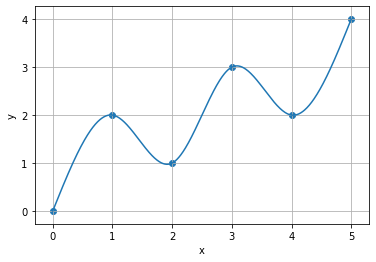

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 2, 1, 3, 2, 4], dtype=float)
 
n = len(x)
m = n - 1

h = np.diff(x)

A = np.zeros(n)
B = np.ones(n)
C = np.zeros(n)
D = np.zeros(n)
 
B[0] = 1
B[-1] = 1
D[0] = 0
D[-1] = 0

def evaluate_spline(x_eval):
    x_eval = np.asarray(x_eval, dtype=float)
    y_eval = np.zeros_like(x_eval)
 
    for i in range(m):
        mask = (x_eval >= x[i]) & (x_eval <= x[i + 1])
        dx   = x_eval[mask] - x[i]
        hi   = h[i]
 
        a = y[i]
        b = (y[i+1] - y[i]) / hi - hi * (2*M[i] + M[i+1]) / 6
        c = M[i] / 2
        d = (M[i+1] - M[i]) / (6 * hi)
 
        y_eval[mask] = a + b*dx + c*dx**2 + d*dx**3
 
    return y_eval

for i in range(1, m):
    A[i] = h[i - 1]
    B[i] = 2 * (h[i - 1] + h[i])
    C[i] = h[i]
    D[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])
    
for i in range(1, n):
    w = A[i] / B[i - 1]
    B[i] = B[i] - w * C[i - 1]
    D[i] = D[i] - w * D[i - 1]

M = np.zeros(n)
M[-1] = D[-1]

for i in range(n - 2, -1, -1):
    M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

xsmooth = np.linspace(x[0], x[-1], 500)
ysmooth = evaluate_spline(xsmooth)

plt.figure()
plt.plot(xsmooth, ysmooth)
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()